# Mutual Fund Performance Analytics

## Objective
Analyze mutual fund performance using return, risk, and benchmark metrics.

Metrics:
- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [102]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
# Load NAV Data
fact_nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

fact_nav['date'] = pd.to_datetime(
    fact_nav['date']
)

fact_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [104]:
print(fact_nav.shape)

print(fact_nav.columns.tolist())

fact_nav.head()

(46000, 3)
['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [105]:
#Sort Data
fact_nav = fact_nav.sort_values(
    ['amfi_code','date']
)

In [106]:
# Calculate Daily Returns
#Convert NAV into daily performance.
fact_nav['daily_return'] = (
    fact_nav.groupby('amfi_code')['nav']
    .pct_change()
)
fact_nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [107]:
fact_nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

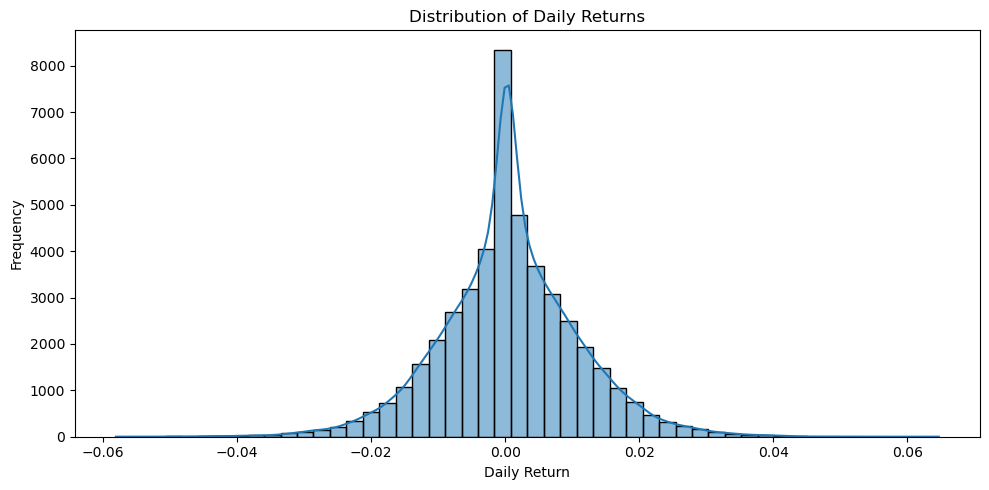

In [108]:
#Return Distribution Chart
plt.figure(figsize=(10,5))

sns.histplot(
    fact_nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Daily Returns"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_17_daily_return_distribution.png",
    dpi=300
)

plt.show()

## Daily Return Distribution Insight

Most daily returns are concentrated around zero, indicating that mutual fund returns generally exhibit small day-to-day fluctuations with occasional extreme movements.

In [109]:
print(fact_nav[['amfi_code','date','nav','daily_return']].head())
print(fact_nav['daily_return'].describe())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


## Daily Return Distribution Insight

The average daily return across all schemes is approximately 0.06%, with most returns concentrated near zero. The highest daily gain observed was 6.47% while the largest daily decline was 5.81%, indicating moderate volatility across the mutual fund universe.

# CAGR Analysis

CAGR (Compound Annual Growth Rate) measures the annualized growth rate of a fund over the analysis period.

In [110]:
cagr_list = []

for code in fact_nav['amfi_code'].unique():

    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ]

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_list.append([
        code,
        cagr
    ])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df['cagr_pct'] = (
    cagr_df['cagr'] * 100
).round(2)

cagr_df.head()

,amfi_code,cagr,cagr_pct
0,100016,0.026352,2.64
1,100025,0.044551,4.46
2,100033,0.300997,30.10
3,101206,0.235205,23.52
4,101207,0.079331,7.93


In [111]:
cagr_df.sort_values(
    'cagr',
    ascending=False
).head(10)

,amfi_code,cagr,cagr_pct
25,120505,0.328016,32.80
21,119598,0.323981,32.40
39,149324,0.322621,32.26
36,148569,0.319245,31.92
34,148567,0.309499,30.95
30,120843,0.308833,30.88
2,100033,0.300997,30.10
38,149323,0.295581,29.56
16,119094,0.281926,28.19
19,119551,0.257849,25.78


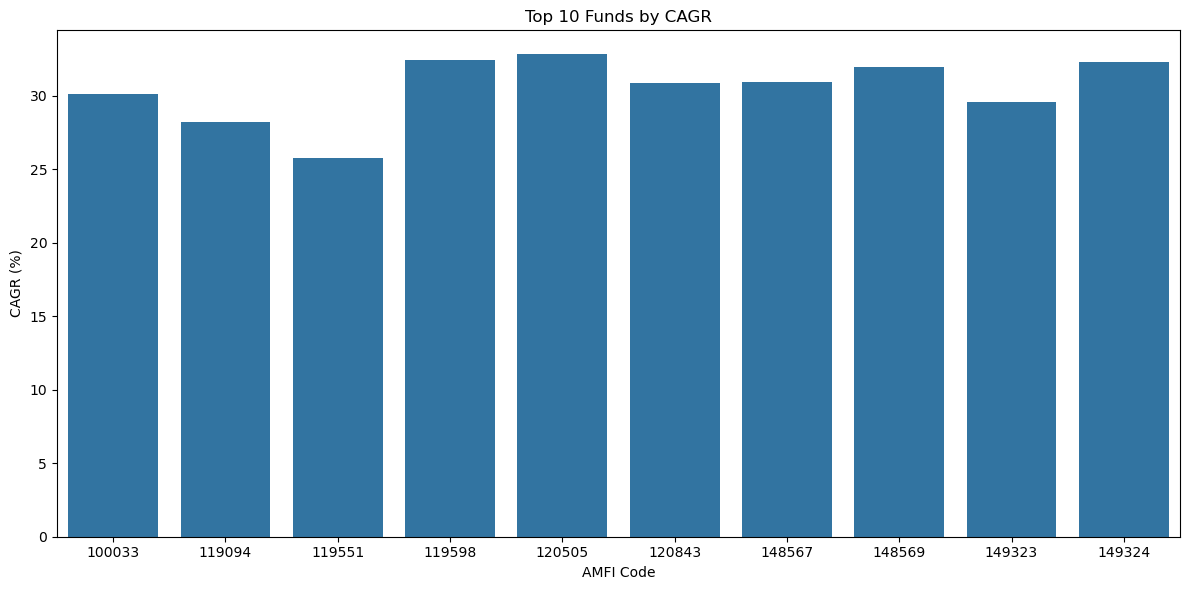

In [112]:
#Chart 
top10_cagr = cagr_df.sort_values(
    'cagr',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_cagr,
    x='amfi_code',
    y='cagr_pct'
)

plt.title(
    'Top 10 Funds by CAGR'
)

plt.xlabel('AMFI Code')

plt.ylabel('CAGR (%)')

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_18_top10_cagr.png',
    dpi=300
)

plt.show()

## CAGR Insight

The top-performing funds generated the highest annualized returns over the analysis period, demonstrating strong long-term wealth creation potential compared to other schemes.

In [113]:
print(cagr_df.shape)
cagr_df.sort_values(
    'cagr',
    ascending=False
).head()

(40, 3)


,amfi_code,cagr,cagr_pct
25,120505,0.328016,32.80
21,119598,0.323981,32.40
39,149324,0.322621,32.26
36,148569,0.319245,31.92
34,148567,0.309499,30.95


In [114]:
import numpy as np

cagr_table = []

for code in fact_nav['amfi_code'].unique():

    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ].sort_values('date')

    end_date = temp['date'].max()
    end_nav = temp['nav'].iloc[-1]

    # 1 Year CAGR
    one_year_data = temp[
        temp['date'] >= end_date - pd.DateOffset(years=1)
    ]

    if len(one_year_data) > 0:
        start_nav_1y = one_year_data['nav'].iloc[0]
        cagr_1y = ((end_nav / start_nav_1y) ** 1 - 1) * 100
    else:
        cagr_1y = np.nan

    # 3 Year CAGR
    three_year_data = temp[
        temp['date'] >= end_date - pd.DateOffset(years=3)
    ]

    if len(three_year_data) > 0:
        start_nav_3y = three_year_data['nav'].iloc[0]
        cagr_3y = ((end_nav / start_nav_3y) ** (1/3) - 1) * 100
    else:
        cagr_3y = np.nan

    cagr_table.append([
        code,
        round(cagr_1y,2),
        round(cagr_3y,2),
        np.nan
    ])

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        'amfi_code',
        'CAGR_1Y',
        'CAGR_3Y',
        'CAGR_5Y'
    ]
)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN


In [115]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

## 5-Year CAGR Note

The available NAV history spans from January 2022 to May 2026. Therefore, 5-Year CAGR could not be computed due to insufficient historical data.

Sharpe Ratio

In [116]:
#Annual Risk-Free Rate to Daily
rf_daily = 0.065 / 252

In [117]:
#Calculate Sharpe for All Funds
import numpy as np

sharpe_list = []

for code in fact_nav['amfi_code'].unique():

    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ]

    returns = temp['daily_return'].dropna()

    avg_return = returns.mean()
    std_return = returns.std()

    sharpe = (
        (avg_return - rf_daily)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append([
        code,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        'amfi_code',
        'Sharpe_Ratio'
    ]
)

In [118]:
#Rank Funds
sharpe_df['Sharpe_Rank'] = (
    sharpe_df['Sharpe_Ratio']
    .rank(ascending=False)
)

sharpe_df = sharpe_df.sort_values(
    'Sharpe_Ratio',
    ascending=False
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0


In [119]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

C:\Temp\ipykernel_39052\2084346207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10['amfi_code'] = top10['amfi_code'].astype(str)


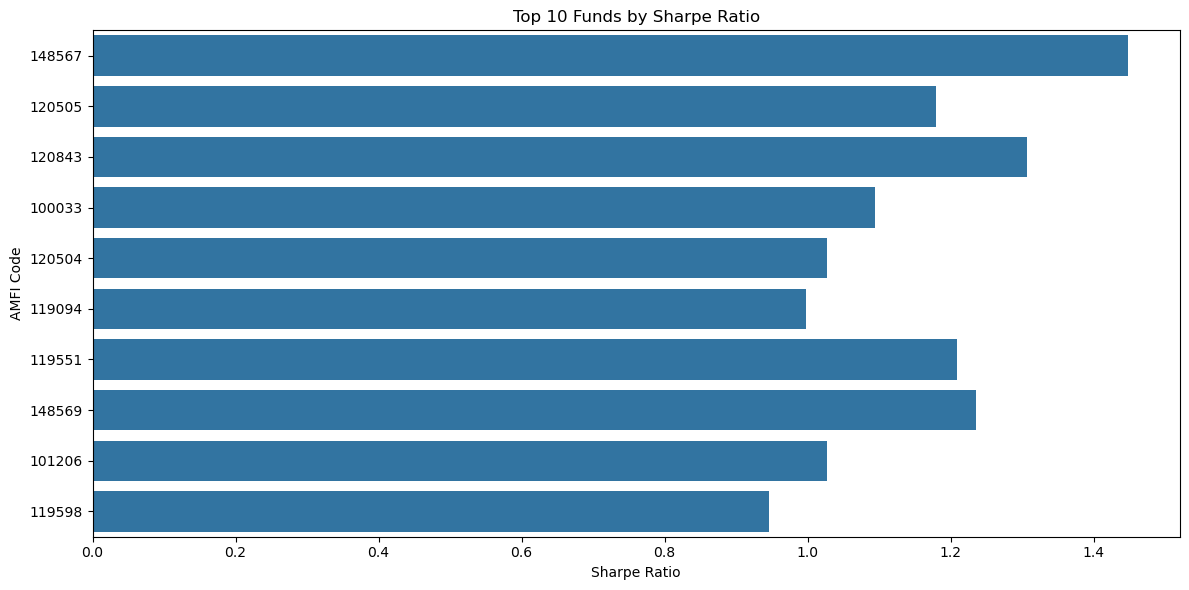

In [120]:
#Chart
top10['amfi_code'] = top10['amfi_code'].astype(str)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Sharpe_Ratio',
    y='amfi_code'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_19_sharpe_ratio.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [121]:
import os

print(os.getcwd())  

c:\Users\hp\Desktop\mutual_fund_project\notebooks


Sortino Ratio

In [122]:
import pandas as pd
import numpy as np

rf = 0.065

sortino_results = []

for code in fact_nav['amfi_code'].unique():

    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ].copy()

    returns = temp['daily_return'].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    if downside_std == 0:
        sortino_ratio = np.nan
    else:
        sortino_ratio = (
            (annual_return - rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_results.append(
        [code, sortino_ratio]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'Sortino_Ratio'
    ]
)

sortino_df = sortino_df.sort_values(
    'Sortino_Ratio',
    ascending=False
)

sortino_df.head()

,amfi_code,Sortino_Ratio
34,148567,601.182382
30,120843,595.808648
36,148569,541.022309
19,119551,539.347317
25,120505,511.396941


In [123]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [124]:
import pandas as pd

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

print(fund_master.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [125]:
#Chart
top10 = sortino_df.head(10)

top10 = top10.merge(
    fund_master[
        ['amfi_code', 'scheme_name']
    ],
    on='amfi_code',
    how='left'
)
print(top10)

   amfi_code  Sortino_Ratio                                        scheme_name
0     148567     601.182382      Mirae Asset Large Cap Fund - Regular - Growth
1     120843     595.808648             Kotak Flexicap Fund - Regular - Growth
2     148569     541.022309      Mirae Asset Tax Saver Fund - Regular - Growth
3     119551     539.347317          SBI Bluechip Fund - Regular Plan - Growth
4     120505     511.396941           ICICI Pru Midcap Fund - Regular - Growth
5     149323     472.525468                 DSP Midcap Fund - Regular - Growth
6     118632     466.233402     Nippon India Large Cap Fund - Regular - Growth
7     100033     460.941758  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8     120504     454.934036          ICICI Pru Bluechip Fund - Direct - Growth
9     101206     453.489844      ABSL Frontline Equity Fund - Regular - Growth


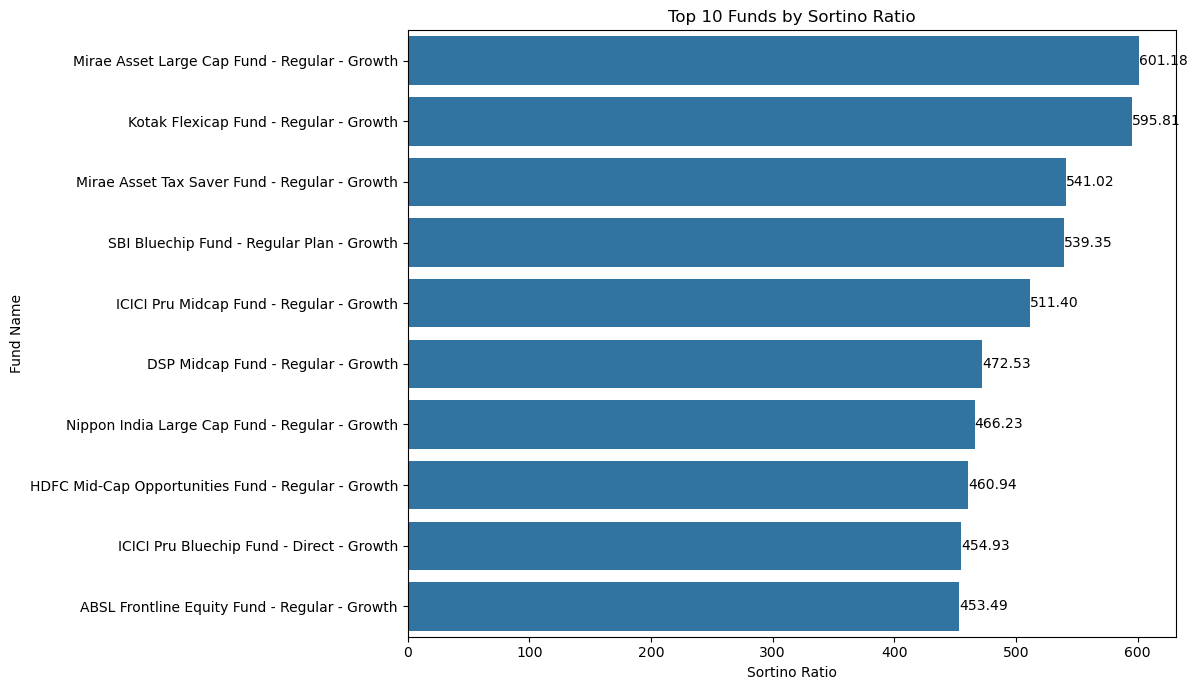

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top10,
    x='Sortino_Ratio',
    y='scheme_name'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xlabel("Sortino Ratio")
plt.ylabel("Fund Name")

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_20_sortino_ratio.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Sortino Ratio Insight

Funds with higher Sortino ratios delivered superior risk-adjusted returns while minimizing downside volatility, making them attractive for conservative long-term investors.

(Chart 20: Sortino Ratio Ranking)

 Alpha & Beta

Beta

Measures how sensitive a fund is to the market.
Beta = 1 → moves like market
Beta > 1 → more volatile than market
Beta < 1 → less volatile than market

Alpha

Measures excess return generated by the fund after accounting for market movement.
Positive Alpha = fund manager added value.
Negative Alpha = underperformed benchmark.

In [127]:
import pandas as pd

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [128]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [129]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [130]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [131]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

In [132]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [133]:
print(fact_nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [134]:
merged = fact_nav.merge(
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

In [135]:
from scipy.stats import linregress

results = []

for code in merged['amfi_code'].unique():

    temp = merged[
        merged['amfi_code'] == code
    ].dropna()

    if len(temp) < 30:
        continue

    reg = linregress(
        temp['benchmark_return'],
        temp['daily_return']
    )

    alpha = reg.intercept * 252
    beta = reg.slope

    results.append([
        code,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [136]:
import os

os.makedirs("reports", exist_ok=True)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

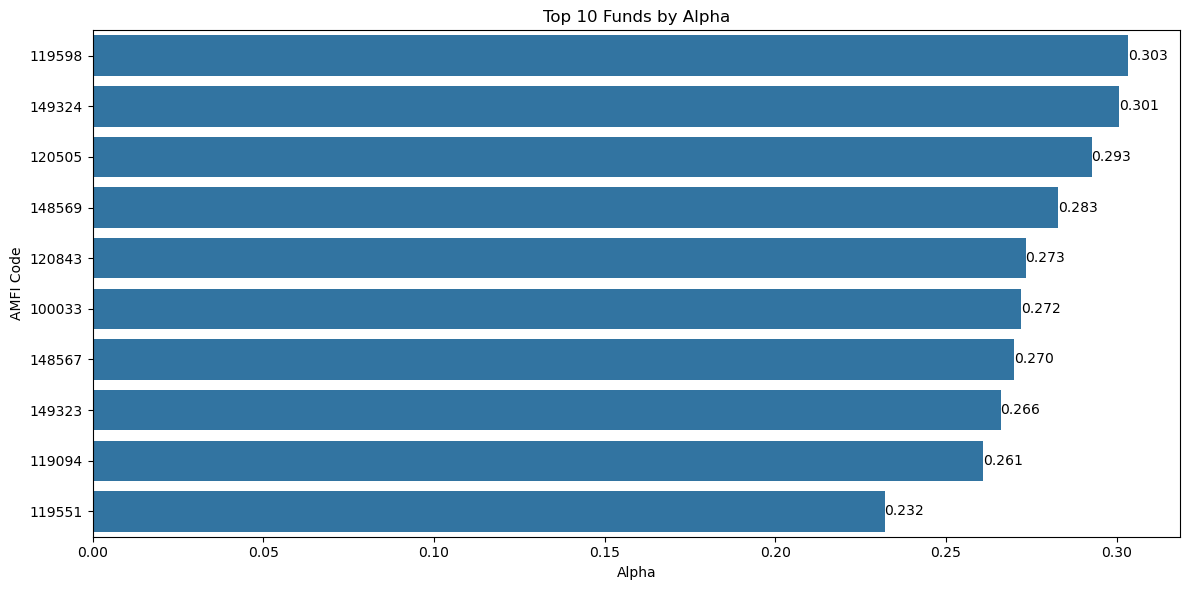

In [137]:
top10_alpha = (
    alpha_beta_df
    .sort_values('alpha', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10_alpha,
    x='alpha',
    y=top10_alpha['amfi_code'].astype(str)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_21_alpha.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Alpha & Beta Insight

Funds with positive alpha generated returns above what would be expected based on their market exposure (beta). Higher beta funds exhibited greater sensitivity to movements in the NIFTY100 benchmark.

Maximum Drawdown (MDD)
It measures the largest loss from a previous peak.

In [138]:
#Calculate MDD
import pandas as pd

mdd_results = []

for code in fact_nav['amfi_code'].unique():

    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ].copy()

    temp = temp.sort_values('date')

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        - 1
    )

    max_dd = temp['drawdown'].min()

    mdd_results.append(
        [code, max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [139]:
mdd_df.describe()

,amfi_code,max_drawdown
count,40.000000,40.000000
mean,120247.000000,-0.178729
std,14534.998667,0.112686
min,100016.000000,-0.525742
25%,118632.750000,-0.215927
50%,119551.500000,-0.163070
75%,120842.250000,-0.117653
max,149324.000000,-0.000977


In [140]:
import os

os.makedirs(
    "reports",
    exist_ok=True
)

mdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

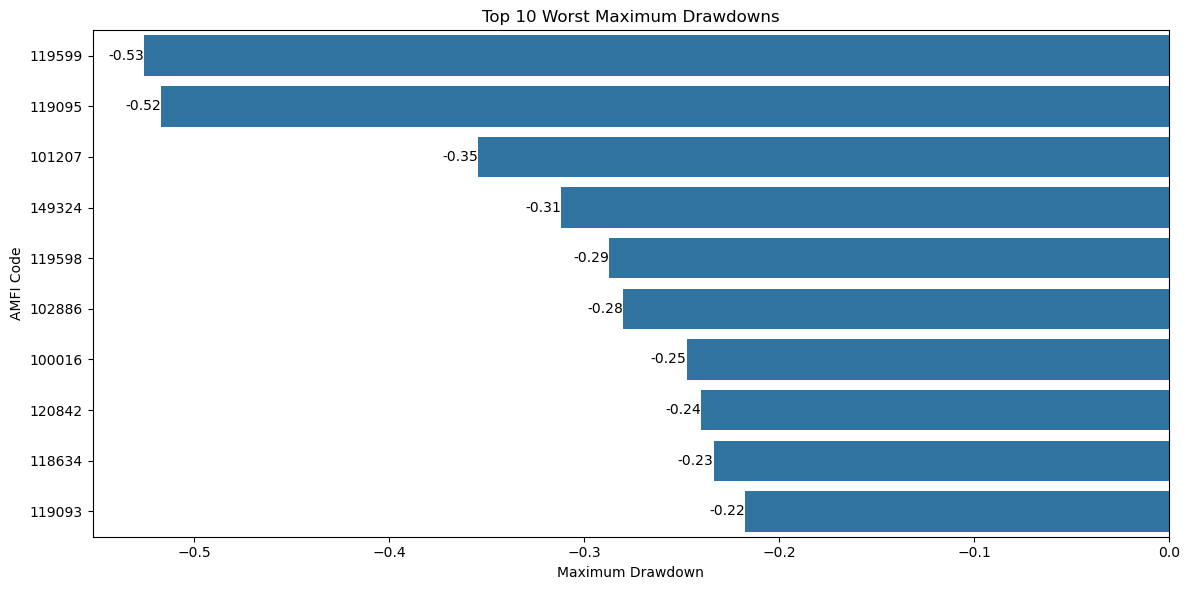

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_mdd = (
    mdd_df
    .sort_values('max_drawdown')
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10_mdd,
    x='max_drawdown',
    y=top10_mdd['amfi_code'].astype(str)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Top 10 Worst Maximum Drawdowns"
)

plt.xlabel(
    "Maximum Drawdown"
)

plt.ylabel(
    "AMFI Code"
)

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_22_max_drawdown.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Maximum Drawdown Insight

Some funds experienced drawdowns exceeding 30%, indicating higher downside risk during market corrections. Funds with smaller drawdowns demonstrated better capital preservation.

Fund Scorecard (0–100)

In [142]:
print(cagr_df.columns.tolist())
cagr_df.head()

['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN


In [143]:
#Load Expence ratio
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

fund_master = fund_master[
    ['amfi_code', 'expense_ratio_pct']
]

fund_master.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [144]:
#Create Scorecard 
scorecard = cagr_df.merge(
    sharpe_df[
        ['amfi_code', 'Sharpe_Ratio']
    ],
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ['amfi_code', 'alpha']
    ],
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    fund_master,
    on='amfi_code'
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,-2.22,1.29,NaN,-0.201517,0.037476,-0.247344,1.55
1,100025,3.70,3.92,NaN,-0.567095,0.042818,-0.043083,0.56
2,100033,53.23,32.44,NaN,1.093699,0.271954,-0.162172,1.38
3,101206,47.92,28.97,NaN,1.027213,0.213998,-0.112916,1.60
4,101207,-23.99,-4.15,NaN,0.162661,0.108971,-0.354469,1.53


In [145]:
#Create Ranking Columns
scorecard['rank_cagr'] = scorecard[
    'CAGR_3Y'
].rank(
    ascending=False
)

scorecard['rank_sharpe'] = scorecard[
    'Sharpe_Ratio'
].rank(
    ascending=False
)

scorecard['rank_alpha'] = scorecard[
    'alpha'
].rank(
    ascending=False
)

scorecard['rank_expense'] = scorecard[
    'expense_ratio_pct'
].rank(
    ascending=True
)

scorecard['rank_mdd'] = scorecard[
    'max_drawdown'
].rank(
    ascending=False
)

In [146]:
#Compute Composite Score
scorecard['fund_score_raw'] = (

    scorecard['rank_cagr'] * 0.30 +

    scorecard['rank_sharpe'] * 0.25 +

    scorecard['rank_alpha'] * 0.20 +

    scorecard['rank_expense'] * 0.15 +

    scorecard['rank_mdd'] * 0.10

)

In [147]:
#Convert to 0–100 Scale
scorecard['fund_score'] = 100 * (

    scorecard['fund_score_raw'].max()

    -

    scorecard['fund_score_raw']

) / (

    scorecard['fund_score_raw'].max()

    -

    scorecard['fund_score_raw'].min()

)

In [148]:
#Checking Top Funds
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

scorecard[
    ['amfi_code', 'fund_score']
].head(10)


,amfi_code,fund_score
34,148567,100.000000
25,120505,94.439618
30,120843,94.092094
2,100033,92.354474
24,120504,91.311903
16,119094,87.141616
19,119551,84.100782
36,148569,82.536924
3,101206,74.891399
21,119598,73.761946


In [149]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

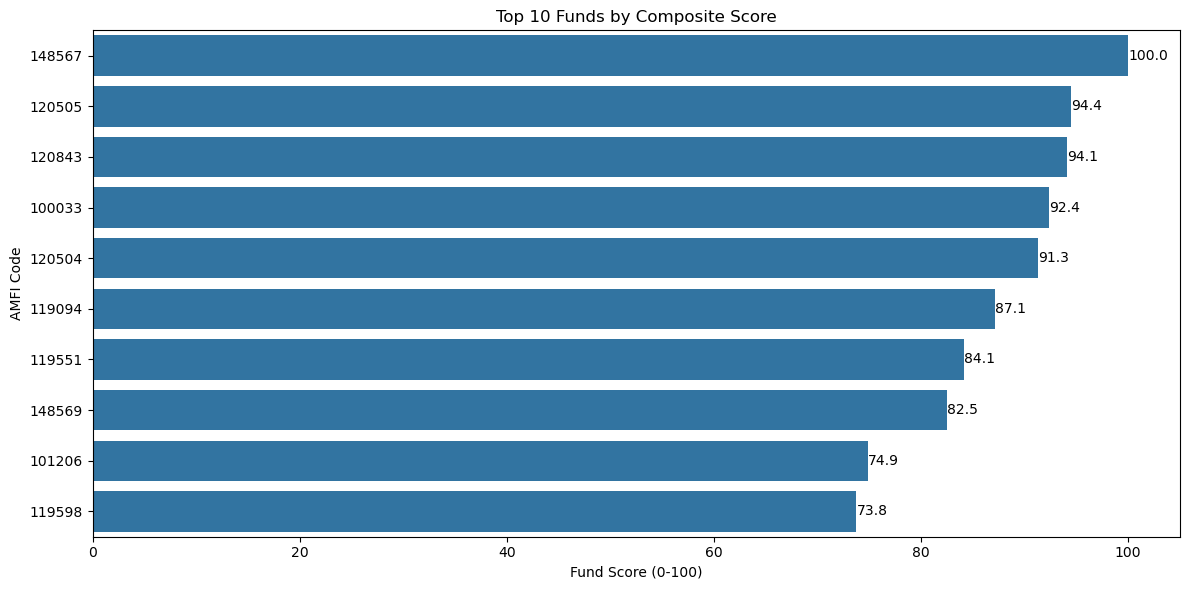

In [150]:
#Chart
import matplotlib.pyplot as plt
import seaborn as sns

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x='fund_score',
    y=top10['amfi_code'].astype(str)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f'
    )

plt.title(
    "Top 10 Funds by Composite Score"
)

plt.xlabel(
    "Fund Score (0-100)"
)

plt.ylabel(
    "AMFI Code"
)

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_23_fund_scorecard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Fund Scorecard Insight

The composite fund score combines long-term returns, risk-adjusted performance, alpha generation, cost efficiency, and downside protection. Funds with the highest scores demonstrated balanced performance across multiple evaluation metrics.

In [151]:
scorecard[['amfi_code','fund_score']].head()

,amfi_code,fund_score
34,148567,100.000000
25,120505,94.439618
30,120843,94.092094
2,100033,92.354474
24,120504,91.311903


Final Task: Benchmark Comparison & Tracking Error

Goal

Compare:

Top 5 Funds (from Scorecard)
NIFTY50
NIFTY100
over the last 3 years

In [152]:
#Get Top 5 Funds
top5_funds = scorecard.head(5)['amfi_code'].tolist()

print(top5_funds)

[148567, 120505, 120843, 100033, 120504]


In [153]:
#Filter NAV data
top5_nav = fact_nav[
    fact_nav['amfi_code'].isin(top5_funds)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [154]:
#Keep last 3 years
top5_nav['date'] = pd.to_datetime(top5_nav['date'])

start_date = top5_nav['date'].max() - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav['date'] >= start_date
]
print(top5_nav)

       amfi_code       date       nav  daily_return
2665      100033 2023-05-29  147.2155      0.004216
2666      100033 2023-05-30  147.2007     -0.000101
2667      100033 2023-05-31  147.4640      0.001789
2668      100033 2023-06-01  146.5954     -0.005890
2669      100033 2023-06-02  145.8015     -0.005416
...          ...        ...       ...           ...
40245     148567 2026-05-25  229.4356     -0.013787
40246     148567 2026-05-26  229.9402      0.002199
40247     148567 2026-05-27  231.1083      0.005080
40248     148567 2026-05-28  233.1530      0.008847
40249     148567 2026-05-29  230.2708     -0.012362

[3925 rows x 4 columns]


In [155]:
#Normalize NAVs
#This converts all funds to start at 100.
top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [156]:
#Preparing Benchmarks
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

bench = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50', 'NIFTY100']
    )
].copy()

bench = bench[
    bench['date'] >= start_date
]

In [157]:
bench['normalized_value'] = (
    bench.groupby('index_name')['close_value']
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

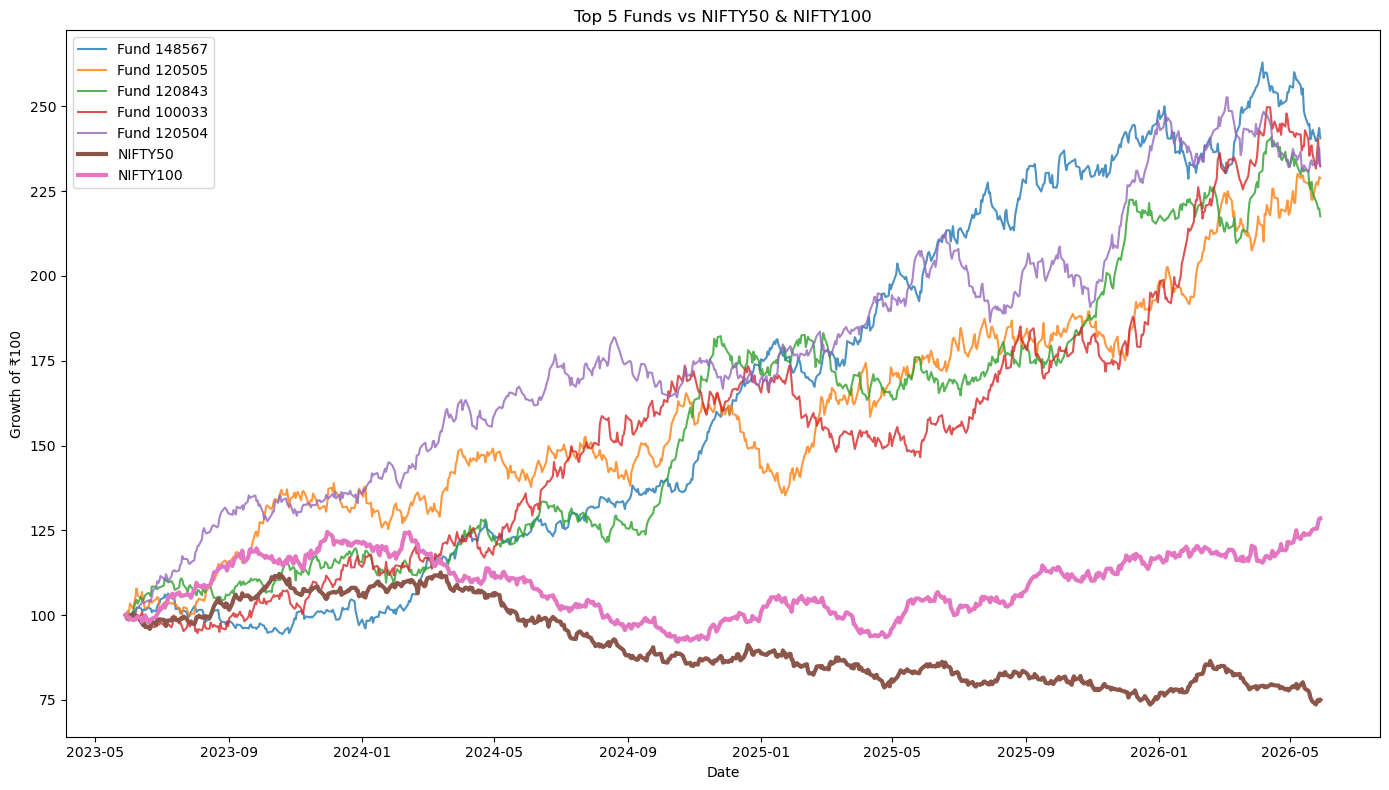

In [158]:
#Plot Comparison Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

# Funds
for fund in top5_funds:

    temp = top5_nav[
        top5_nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=f"Fund {fund}",
        alpha=0.8
    )

# Benchmarks
for idx in ['NIFTY50', 'NIFTY100']:

    temp = bench[
        bench['index_name'] == idx
    ]

    plt.plot(
        temp['date'],
        temp['normalized_value'],
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend()

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_24_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [159]:
#Tracking Error
#Tracking Error =
#Std(Fund Return - Benchmark Return) × √252

from numpy import sqrt

tracking_results = []

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

for fund in top5_funds:

    temp = fact_nav[
        fact_nav['amfi_code'] == fund
    ][['date','daily_return']]

    merged = temp.merge(
        nifty100[
            ['date','benchmark_return']
        ],
        on='date'
    ).dropna()

    tracking_error = (
        (merged['daily_return']
         -
         merged['benchmark_return']
        ).std()
        *
        sqrt(252)
    )

    tracking_results.append(
        [fund, tracking_error]
    )

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_df

,amfi_code,tracking_error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,100033,0.228699
4,120504,0.191587


In [160]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

## Benchmark Comparison Insight

The top-ranked funds outperformed benchmark indices over the analysis period, demonstrating superior risk-adjusted returns. Funds with higher tracking error deviated more from benchmark performance, reflecting active portfolio management strategies.

In [161]:
print(cagr_df.shape)
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(mdd_df.shape)
print(scorecard.shape)

(40, 4)
(40, 3)
(40, 3)
(40, 2)
(40, 15)


# Project Summary

This project analyzed 40 mutual fund schemes from 2022–2026 using both exploratory data analysis and performance analytics.

Key metrics evaluated:
- NAV Trends
- AUM Growth
- SIP Inflows
- Category Flows
- Investor Demographics
- Folio Growth
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

The analysis identified the top-performing funds based on a composite score combining returns, risk-adjusted performance, downside protection, alpha generation, and cost efficiency.

In [168]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/processed/bluestock_mf.db")

fact_nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

fact_aum = pd.read_sql(
    "SELECT * FROM fact_aum",
    conn
)

fact_nav.to_csv(
    "data/processed/fact_nav.csv",
    index=False
)

fact_aum.to_csv(
    "data/processed/fact_aum.csv",
    index=False
)

conn.close()

OSError: Cannot save file into a non-existent directory: 'data\processed'

In [164]:
conn = sqlite3.connect("bluestock_mf.db")

In [169]:
fact_nav.to_csv(
    "fact_nav.csv",
    index=False
)

fact_aum.to_csv(
    "fact_aum.csv",
    index=False
)

print("CSV files exported successfully")

CSV files exported successfully


In [170]:
import os
print(os.listdir())

['01_data_ingestion.ipynb.ipynb', 'bluestock_mf.db', 'data', 'EDA_Analysis.ipynb', 'exported_charts', 'fact_aum.csv', 'fact_nav.csv', 'Performance_Analytics.ipynb', 'reports']
